In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [11]:
import os, glob, random, json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import Counter
import matplotlib.pyplot as plt

In [14]:
DATA_DIR = "/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"

IMG_SIZE = 128
BATCH_SIZE = 64
SEED = 42
MIN_IMAGES_PER_ID = 10
TOP_K = 200  # adjust 200–500 depending on GPU/time

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [15]:
people = []
for person in os.listdir(DATA_DIR):
    pdir = os.path.join(DATA_DIR, person)
    if not os.path.isdir(pdir):
        continue
    imgs = glob.glob(os.path.join(pdir, "*.jpg")) + glob.glob(os.path.join(pdir, "*.png"))
    if len(imgs) >= MIN_IMAGES_PER_ID:
        people.append((person, len(imgs)))

people.sort(key=lambda x: x[1], reverse=True)
people = people[:TOP_K]

class_names = [p for p, _ in people]
class_to_idx = {c: i for i, c in enumerate(class_names)}

print("Classes kept:", len(class_names))
print("Top 5:", people[:5])

Classes kept: 158
Top 5: [('George_W_Bush', 530), ('Colin_Powell', 236), ('Tony_Blair', 144), ('Donald_Rumsfeld', 121), ('Gerhard_Schroeder', 109)]


In [16]:
train_paths, train_labels = [], []
val_paths, val_labels = [], []

for person, _ in people:
    pdir = os.path.join(DATA_DIR, person)
    imgs = glob.glob(os.path.join(pdir, "*.jpg")) + glob.glob(os.path.join(pdir, "*.png"))
    random.shuffle(imgs)

    n = len(imgs)
    n_train = int(0.8 * n)

    # enforce at least 1 train and 1 val
    n_train = min(max(1, n_train), n - 1)

    tr = imgs[:n_train]
    va = imgs[n_train:]

    label = class_to_idx[person]
    train_paths.extend(tr)
    train_labels.extend([label] * len(tr))
    val_paths.extend(va)
    val_labels.extend([label] * len(va))

print("Train images:", len(train_paths), "Val images:", len(val_paths))

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)

print("Min train imgs/class:", min(train_counts.values()))
print("Min val imgs/class:", min(val_counts.values()))
print("Classes missing in val:", sum(1 for c in range(len(class_names)) if c not in val_counts))

NUM_CLASSES = len(class_names)

# Save mapping (same style as your CNN notebook)
OUT_DIR = "/kaggle/working/vgg_classifier"
os.makedirs(OUT_DIR, exist_ok=True)

with open(os.path.join(OUT_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

Train images: 3397 Val images: 927
Min train imgs/class: 8
Min val imgs/class: 2
Classes missing in val: 0


In [17]:
def load_image(fp, y):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0  # [-1, 1] exactly like your CNN notebook
    return img, y

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(2000, seed=SEED).map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

I0000 00:00:1771574674.859195      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [18]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
], name="aug")

def vgg_block(x, filters, convs, name_prefix):
    for i in range(convs):
        x = layers.Conv2D(filters, (3,3), padding="same", activation="relu",
                          kernel_initializer="he_normal",
                          name=f"{name_prefix}_conv{i+1}")(x)
    x = layers.MaxPooling2D((2,2), strides=2, name=f"{name_prefix}_pool")(x)
    return x

def build_vgg_based_classifier(num_classes):
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = augment(inp)

    # VGG-ish configuration adapted for 128x128
    # (similar spirit to VGG16: stacks of 2-3 convs then pooling)
    x = vgg_block(x, 64,  2, "b1")   # 128 -> 64
    x = vgg_block(x, 128, 2, "b2")   # 64 -> 32
    x = vgg_block(x, 256, 3, "b3")   # 32 -> 16
    x = vgg_block(x, 512, 3, "b4")   # 16 -> 8
    x = vgg_block(x, 512, 3, "b5")   # 8 -> 4

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(512, activation="relu", kernel_initializer="he_normal", name="fc1")(x)
    x = layers.Dropout(0.5, name="drop1")(x)
    out = layers.Dense(num_classes, activation="softmax", name="softmax")(x)

    return keras.Model(inp, out, name="VGG_Based_Softmax_Classifier")

model = build_vgg_based_classifier(NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "VGG_Based_Softmax_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv3 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pool (MaxPooling2D)          │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv1 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv2 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv3 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_pool (MaxPooling2D)          │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv1 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv2 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv3 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_pool (MaxPooling2D)          │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Dense)                 │ (None, 158)            │        81,054 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,990,558 (72.44 MB)

 Trainable params: 18,990,558 (72.44 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
best_path = os.path.join(OUT_DIR, "best.weights.h5")

ckpt = keras.callbacks.ModelCheckpoint(
    best_path, monitor="val_accuracy", mode="max",
    save_best_only=True, save_weights_only=True, verbose=1
)

early = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max", patience=7,
    restore_best_weights=True, verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, verbose=1
)

hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[ckpt, early, reduce_lr]
)

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(hist.history, f, indent=2)

print("Saved best weights to:", best_path)

Epoch 1/25


I0000 00:00:1771574748.161078     168 service.cc:152] XLA service 0x789de4002760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771574748.161119     168 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771574749.061718     168 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/54 ━━━━━━━━━━━━━━━━━━━━ 19:06 22s/step - accuracy: 0.0000e+00 - loss: 5.6300

I0000 00:00:1771574765.827000     168 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.1089 - loss: 4.7512
Epoch 1: val_accuracy improved from -inf to 0.11435, saving model to /kaggle/working/vgg_classifier/best.weights.h5
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 464ms/step - accuracy: 0.1089 - loss: 4.7515 - val_accuracy: 0.1143 - val_loss: 4.6522 - learning_rate: 3.0000e-04
Epoch 2/25
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.1485 - loss: 4.4680
Epoch 2: val_accuracy did not improve from 0.11435
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.1475 - loss: 4.4737 - val_accuracy: 0.1143 - val_loss: 4.5483 - learning_rate: 3.0000e-04
Epoch 3/25
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.1424 - loss: 4.2583
Epoch 3: val_accuracy did not improve from 0.11435
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.1414 - loss: 4.2670 - val_accuracy: 0.1143 - val_loss: 4.5500 - learning_rate: 3.0000e-04
Epoch 4/25
53/54 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.1301 - loss: 4.3002
Epoch 4: val_

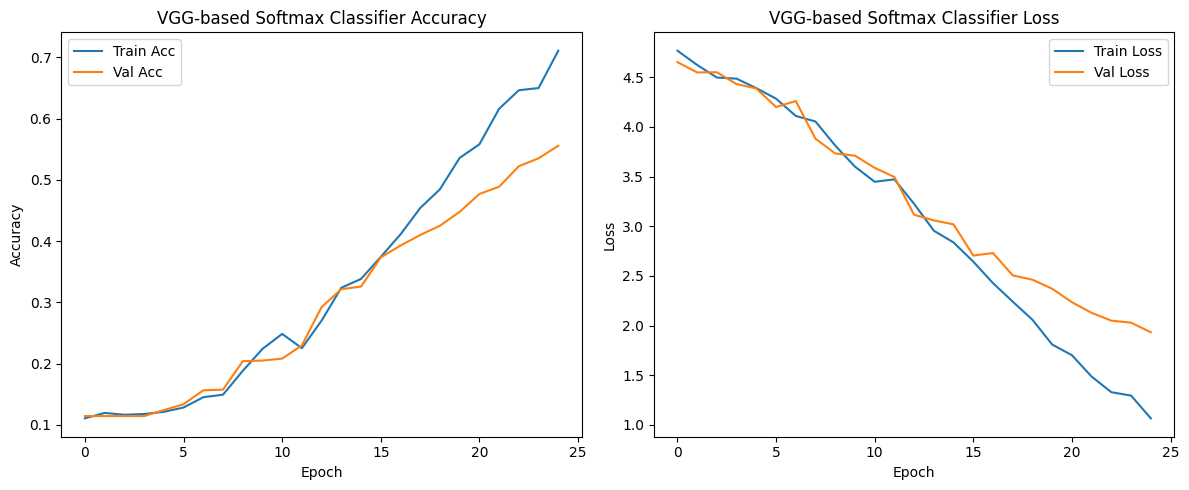

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist.history["accuracy"], label="Train Acc")
plt.plot(hist.history["val_accuracy"], label="Val Acc")
plt.title("VGG-based Softmax Classifier Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["loss"], label="Train Loss")
plt.plot(hist.history["val_loss"], label="Val Loss")
plt.title("VGG-based Softmax Classifier Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

Best weights loaded.


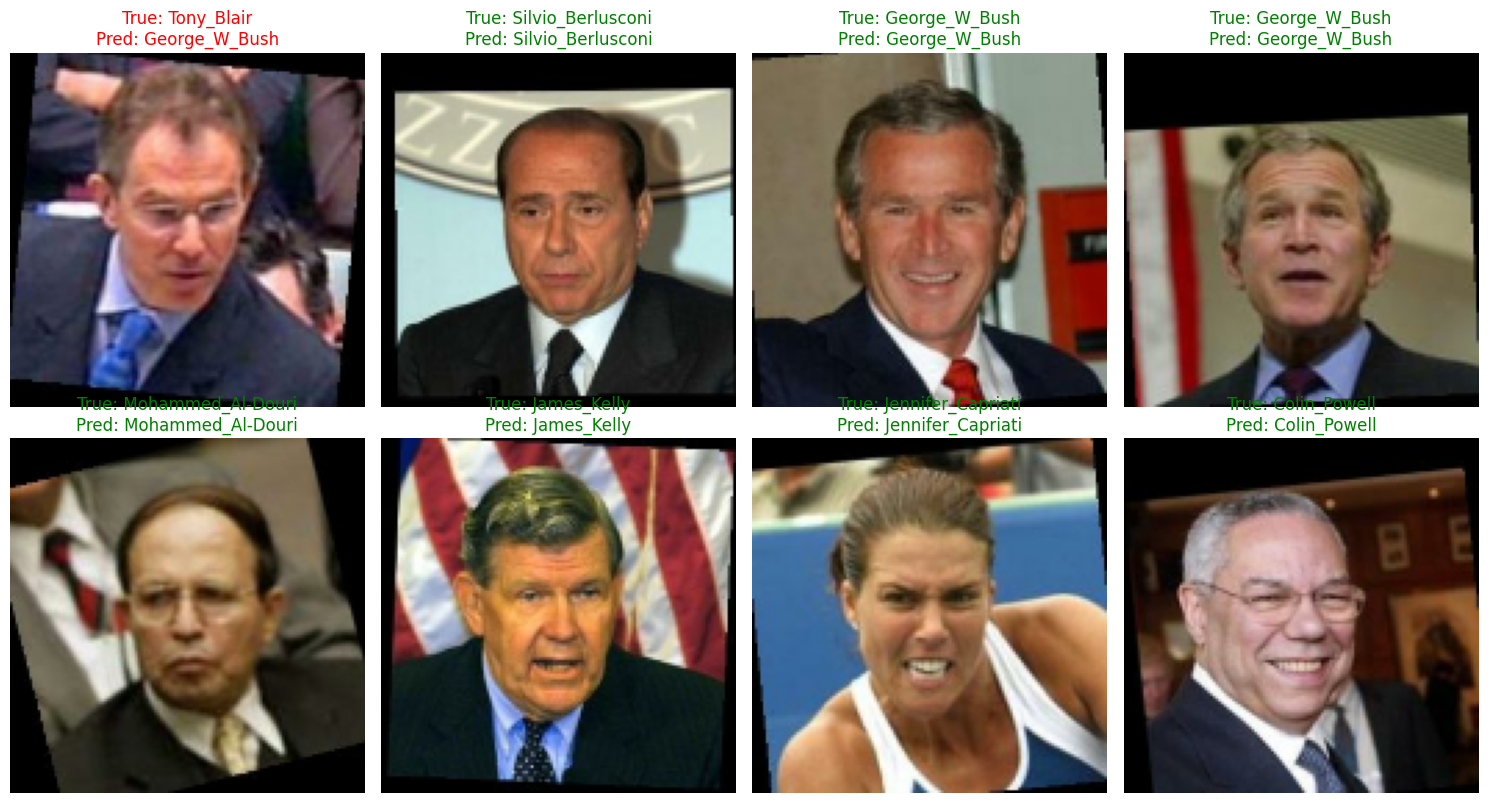

In [21]:
model.load_weights(best_path)
print("Best weights loaded.")

idxs = np.random.choice(len(val_paths), size=8, replace=False)

imgs = []
true_ids = []
for i in idxs:
    fp = val_paths[i]
    y = val_labels[i]

    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    imgs.append(img)
    true_ids.append(y)

imgs = tf.stack(imgs, axis=0)
probs = model.predict(imgs, verbose=0)
preds = np.argmax(probs, axis=1)

plt.figure(figsize=(15,8))
for k in range(8):
    plt.subplot(2,4,k+1)
    show = (imgs[k].numpy() + 1) / 2
    plt.imshow(show)
    plt.axis("off")

    t = class_names[true_ids[k]]
    p = class_names[preds[k]]
    color = "green" if t == p else "red"
    plt.title(f"True: {t}\nPred: {p}", color=color)

plt.tight_layout()
plt.show()